<a href="https://colab.research.google.com/github/JhanuarC/RNA-Trabajo-3/blob/main/creacion_dataset_y_regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

fechas = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
estados = ['Uttar Pradesh', 'Goa', 'Rajasthan', 'Kerala', 'Jammu and Kashmir']

pesos_atractivo = {
    'Uttar Pradesh': 200,
    'Rajasthan': 150,
    'Goa': 130,
    'Kerala': 120,
    'Jammu and Kashmir': 110
}

rutas = [f"{orig} - {dest}" for orig in estados for dest in estados if orig != dest]
car_types = ["luxury_bus", "tourist_van", "train_express"]
payment_methods = ["cash", "card", "upi_mobile"]

data_list = []

# Mapeo de factores para optimizar velocidad de procesamiento
factores_vehiculo = {"train_express": 2.5, "luxury_bus": 1.2, "tourist_van": 0.6}

for ruta in rutas:
    orig, dest = ruta.split(' - ')
    demanda_base_ruta = (pesos_atractivo[orig] + pesos_atractivo[dest]) / 2

    for idx, fecha in enumerate(fechas):
        mes = fecha.month
        dia_semana = fecha.weekday()

        # --- VARIABLE 3: ESTACIONALIDAD REGIONAL ---
        factor_estacional_regional = 1.0
        if dest == 'Jammu and Kashmir':
            if mes in [5, 6, 7, 8]: factor_estacional_regional = 1.8   # Verano: Temporada Alta
            elif mes in [12, 1]: factor_estacional_regional = 0.4      # Invierno: Temporada Baja
        elif dest in ['Goa', 'Kerala']:
            if mes in [11, 12, 1]: factor_estacional_regional = 2.0    # Invierno: Temporada Alta
            elif mes in [6, 7, 8]: factor_estacional_regional = 0.5    # Monzones: Temporada Baja
        elif dest in ['Uttar Pradesh', 'Rajasthan']:
            if mes in [10, 11, 12, 1, 2]: factor_estacional_regional = 1.5 # Clima agradable
            elif mes in [5, 6]: factor_estacional_regional = 0.6              # Calor extremo

        # --- COMPONENTE TEMPORAL Y SEMANAL (Ajustado el bug del domingo) ---
        tendencia = idx * 0.02
        estacionalidad_semanal = 25 if dia_semana in [4, 5] else (-35 if dia_semana == 6 else 0)

        for car in car_types:
            factor_car = factores_vehiculo[car]

            for payment in payment_methods:
                # --- VARIABLE 2: MÉTODO DE PAGO ---
                if payment == "upi_mobile" and (fecha.day in [15, 30, 31]):
                    factor_payment = 15
                elif payment == "card" and dia_semana in [4, 5]:
                    factor_payment = 10
                else:
                    factor_payment = 0

                # --- RUIDO ---
                ruido = np.random.normal(loc=0, scale=8)

                # --- CÁLCULO FINAL ---
                demanda_segmentada = (demanda_base_ruta * factor_estacional_regional * factor_car) \
                                     + tendencia + estacionalidad_semanal + factor_payment + ruido

                demanda_segmentada = max(2, int(demanda_segmentada))

                data_list.append({
                    'fecha': fecha,
                    'ruta': ruta,
                    'origen': orig,
                    'destino': dest,
                    'car_type': car,
                    'payment_method': payment,
                    'demanda_pasajeros': demanda_segmentada
                })

df_complejo = pd.DataFrame(data_list)
df_complejo.to_csv("demanda_transporte_india_final.csv", index=False)
print(f"Dataset generado exitosamente con {df_complejo.shape[0]} registros.")

Dataset generado exitosamente con 131580 registros.


## Procesamiento de Datos


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Cargar el dataset generado en el paso anterior
df = pd.read_csv("demanda_transporte_india_final.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Extraer características numéricas de la fecha (Crucial para Regresión)
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.weekday
df['es_fin_de_semana'] = df['dia_semana'].isin([4, 5]).astype(int) # Viernes y Sábados masivos
df['dia_mes'] = df['fecha'].dt.day

# 3. Aplicar One-Hot Encoding a las variables categóricas (Ruta, Car_Type, Payment_Method, Origen, Destino)
# Esto convierte las palabras en columnas de 0 y 1
df_encoded = pd.get_dummies(df, columns=['ruta', 'car_type', 'payment_method', 'origen', 'destino'], drop_first=True)


X = df_encoded.drop(columns=['fecha', 'demanda_pasajeros'])
y = df_encoded['demanda_pasajeros']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Características preparadas para el modelo: {list(X.columns)}")

Características preparadas para el modelo: ['mes', 'dia_semana', 'es_fin_de_semana', 'dia_mes', 'ruta_Goa - Kerala', 'ruta_Goa - Rajasthan', 'ruta_Goa - Uttar Pradesh', 'ruta_Jammu and Kashmir - Goa', 'ruta_Jammu and Kashmir - Kerala', 'ruta_Jammu and Kashmir - Rajasthan', 'ruta_Jammu and Kashmir - Uttar Pradesh', 'ruta_Kerala - Goa', 'ruta_Kerala - Jammu and Kashmir', 'ruta_Kerala - Rajasthan', 'ruta_Kerala - Uttar Pradesh', 'ruta_Rajasthan - Goa', 'ruta_Rajasthan - Jammu and Kashmir', 'ruta_Rajasthan - Kerala', 'ruta_Rajasthan - Uttar Pradesh', 'ruta_Uttar Pradesh - Goa', 'ruta_Uttar Pradesh - Jammu and Kashmir', 'ruta_Uttar Pradesh - Kerala', 'ruta_Uttar Pradesh - Rajasthan', 'car_type_tourist_van', 'car_type_train_express', 'payment_method_cash', 'payment_method_upi_mobile', 'origen_Jammu and Kashmir', 'origen_Kerala', 'origen_Rajasthan', 'origen_Uttar Pradesh', 'destino_Jammu and Kashmir', 'destino_Kerala', 'destino_Rajasthan', 'destino_Uttar Pradesh']


In [4]:
# 1. Inicializar y entrenar el modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 2. Realizar predicciones sobre el set de prueba
y_pred = modelo_lineal.predict(X_test)

# 3. Calcular Métricas de Evaluación (Exigidas en la Rúbrica)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} pasajeros")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} pasajeros")


--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---
MAE (Error Absoluto Medio): 77.18 pasajeros
RMSE (Raíz del Error Cuadrático Medio): 106.93 pasajeros


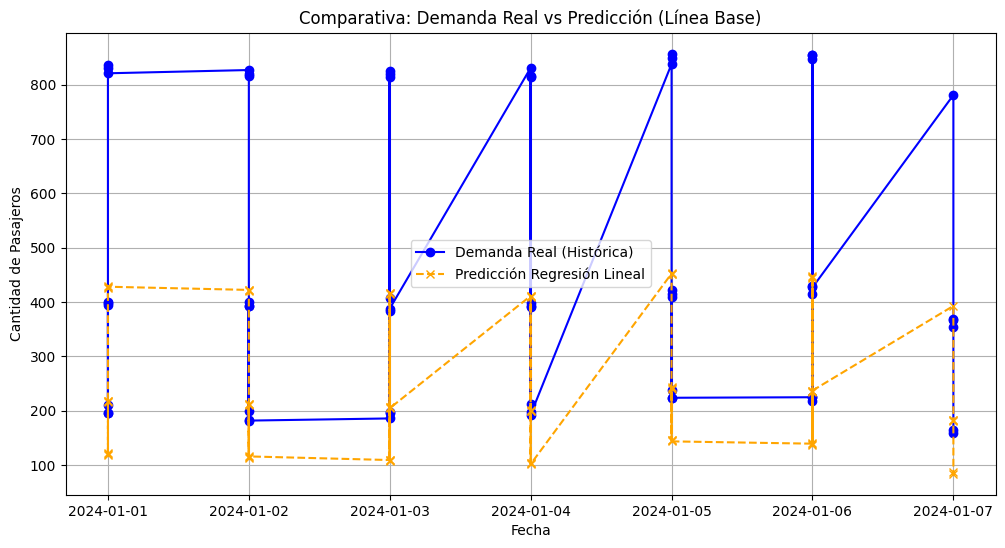

In [5]:
# Crear un subset de prueba ordenado cronológicamente para una visualización clara
df_visualizacion = df_encoded[df_encoded['ruta_Uttar Pradesh - Goa'] == 1].sort_values('fecha').head(60)

X_vis = df_visualizacion.drop(columns=['fecha', 'demanda_pasajeros'])
y_vis = df_visualizacion['demanda_pasajeros']
y_pred_vis = modelo_lineal.predict(X_vis)


plt.figure(figsize=(12, 6))
plt.plot(df_visualizacion['fecha'], y_vis, label='Demanda Real (Histórica)', color='blue', marker='o')
plt.plot(df_visualizacion['fecha'], y_pred_vis, label='Predicción Regresión Lineal', color='orange', linestyle='--', marker='x')
plt.title('Comparativa: Demanda Real vs Predicción (Línea Base)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import tensorflow as tf

# Lista los dispositivos físicos disponibles
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", len(gpus))

if gpus:
    print("Dispositivos detectados:", gpus)
else:
    print("No se detectó ninguna GPU configurada para TensorFlow.")


GPUs disponibles: 1
Dispositivos detectados: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN PARA USO DE GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que la memoria crezca según sea necesario
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Entrenando en GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
# -------------------------------------

# 1. Cargar y Preparar Datos
df = pd.read_csv("demanda_transporte_india_final.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

df_encoded = pd.get_dummies(df, columns=['car_type', 'payment_method'], drop_first=False)
columnas_features = ['demanda_pasajeros'] + [col for col in df_encoded.columns if 'car_type_' in col or 'payment_method_' in col]

# 2. Escalamiento
scaler = MinMaxScaler(feature_range=(0, 1))
df_encoded[columnas_features] = scaler.fit_transform(df_encoded[columnas_features])

# 3. Creación de Secuencias 3D
VENTANA = 14
X, y = [], []
fechas_y = []

for nombre, grupo in df_encoded.groupby(['ruta']):
    combinaciones = grupo.groupby([c for c in df_encoded.columns if 'car_type_' in c or 'payment_method_' in c])
    for _, comb_grupo in combinaciones:
        comb_grupo = comb_grupo.sort_values('fecha')
        matriz_datos = comb_grupo[columnas_features].values
        fechas_grupo = comb_grupo['fecha'].values
        for i in range(len(matriz_datos) - VENTANA):
            X.append(matriz_datos[i : i + VENTANA])
            y.append(matriz_datos[i + VENTANA, 0])
            fechas_y.append(fechas_grupo[i + VENTANA])

X, y, fechas_y = np.array(X), np.array(y), np.array(fechas_y)

# 4. División Cronológica
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
fechas_test = fechas_y[split_idx:]

# 5. Arquitectura del Modelo (Optimizada para GPU)
with tf.device('/GPU:0'):
    modelo_lstm = Sequential([
        LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        BatchNormalization(), # Normaliza las activaciones de la LSTM anterior
        Dropout(0.3),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    modelo_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- LOS MEJORES AMIGOS DE TU GPU: CALLBACKS ---
callbacks_lista = [
    # Detiene el entrenamiento si el modelo deja de mejorar en validación
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),

    # Reduce el ritmo de aprendizaje si te estancas, para afinar la puntería
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

# Entrenamos con más épocas, los callbacks controlarán el final óptimo
historial = modelo_lstm.fit(
    X_train, y_train,
    epochs=50, # Subimos a 50 porque EarlyStopping protegerá el modelo
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks_lista,
    verbose=1
)

# 7. Predicción y Des-escalamiento
predicciones_escaladas = modelo_lstm.predict(X_test)
matriz_inversa_pred = np.zeros((len(predicciones_escaladas), len(columnas_features)))
matriz_inversa_pred[:, 0] = predicciones_escaladas[:, 0]
y_pred_real = scaler.inverse_transform(matriz_inversa_pred)[:, 0]

matriz_inversa_test = np.zeros((len(y_test), len(columnas_features)))
matriz_inversa_test[:, 0] = y_test
y_test_real = scaler.inverse_transform(matriz_inversa_test)[:, 0]

# 8. Evaluación Final
mae_lstm = mean_absolute_error(y_test_real, y_pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"\n--- METRICAS DE EVALUACIÓN ---\nMAE: {mae_lstm:.2f}\nRMSE: {rmse_lstm:.2f}")

# Calcular el Error Porcentual Absoluto Medio (MAPE)
# Añadimos un pequeño valor (1e-5) en el denominador para evitar divisiones por cero si hay demanda 0
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-5))) * 100

# Calcular una métrica de precisión intuitiva para el blog (100% - MAPE)
accuracy_regresion = max(0, 100 - mape)

print(f"MAPE (Error Porcentual Medio): {mape:.2f}%")
print(f"Precisión Equivalente del Modelo: {accuracy_regresion:.2f}%")

Physical devices cannot be modified after being initialized


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0343 - mae: 0.1195 - val_loss: 0.0040 - val_mae: 0.0450 - learning_rate: 0.0010
Epoch 2/50
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.0046 - mae: 0.0507 - val_loss: 0.0030 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 3/50
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0030 - mae: 0.0407 - val_loss: 0.0024 - val_mae: 0.0347 - learning_rate: 0.0010
Epoch 4/50
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0025 - mae: 0.0368 - val_loss: 0.0025 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 5/50
1610/1614 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - mae: 0.0347
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0021 - mae: 0.0342 - val_loss: 0.0039 - val_mae: 0.0470 - learning_rate: 0.0010
Epoch 6/50
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0018 - mae: 0.0310 - val_loss: 0.0032 - val_mae: 0.0395 

In [11]:
import joblib

# 1. Guardar la arquitectura y los pesos de la red LSTM
modelo_lstm.save('modelo_lstm_transporte.keras')
print("Modelo LSTM guardado exitosamente como 'modelo_lstm_transporte.keras'")

# 2. Guardar el escalador (Crucial para preprocesar nuevos datos en la herramienta web)
joblib.dump(scaler, 'scaler_transporte.pkl')
print("Escalador guardado exitosamente como 'scaler_transporte.pkl'")

Modelo LSTM guardado exitosamente como 'modelo_lstm_transporte.keras'
Escalador guardado exitosamente como 'scaler_transporte.pkl'


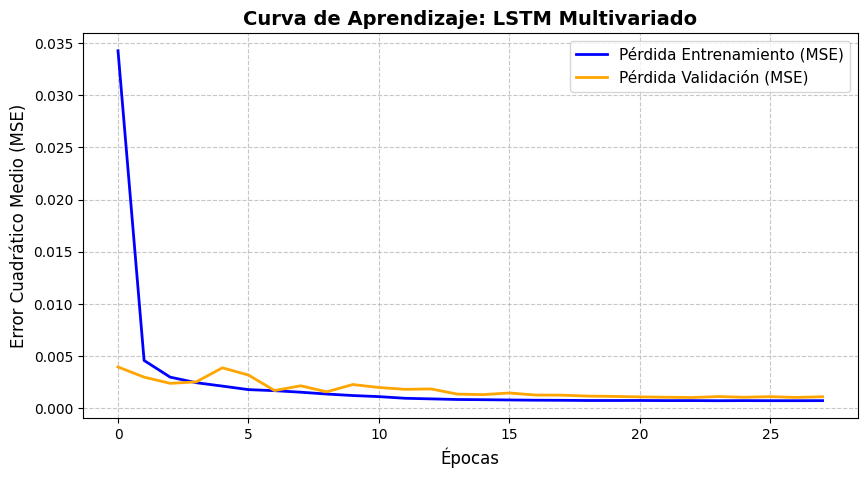

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (MSE)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Pérdida Validación (MSE)', color='orange', linewidth=2)

plt.title('Curva de Aprendizaje: LSTM Multivariado', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Guardar imagen en alta calidad
plt.savefig('curva_aprendizaje_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

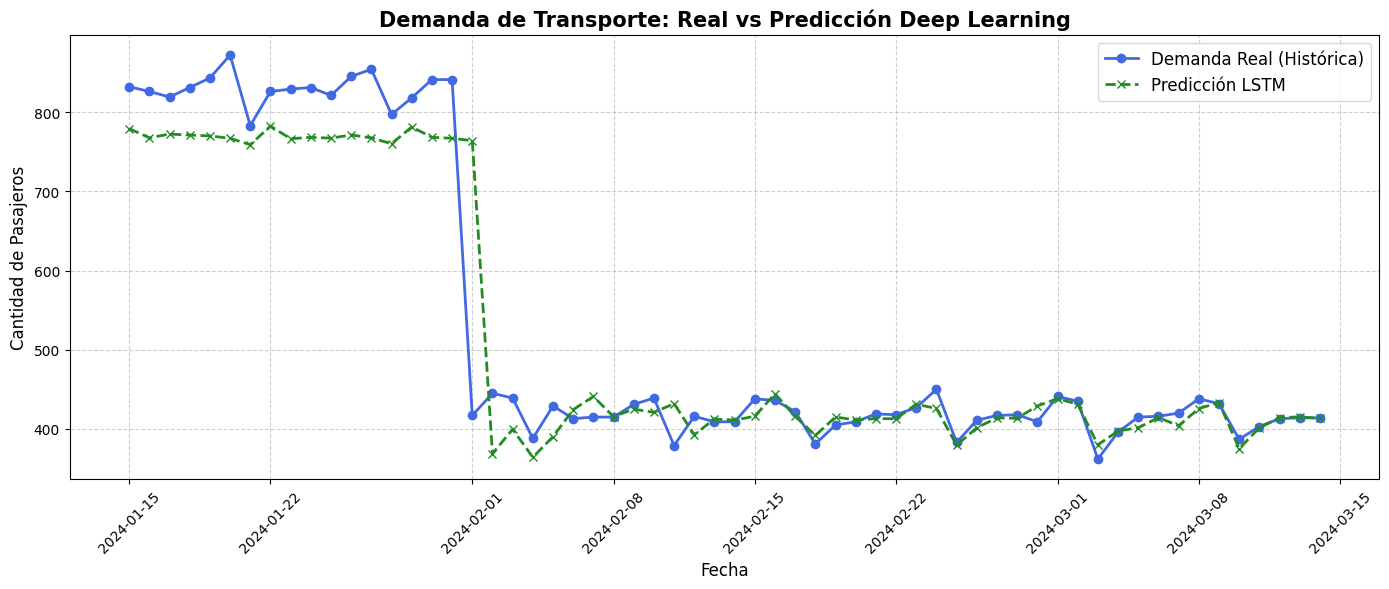

In [18]:
# Seleccionamos un segmento representativo de los datos de prueba (ej. 60 registros)
rango_visual = 60

plt.figure(figsize=(14, 6))

plt.plot(fechas_test[:rango_visual], y_test_real[:rango_visual],
         label='Demanda Real (Histórica)', color='royalblue', marker='o', linewidth=2)

plt.plot(fechas_test[:rango_visual], y_pred_real[:rango_visual],
         label='Predicción LSTM', color='forestgreen', linestyle='--', marker='x', linewidth=2)

plt.title('Demanda de Transporte: Real vs Predicción Deep Learning', fontsize=15, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mejorar la visualización de las fechas en el eje X
plt.xticks(rotation=45)
plt.tight_layout() # Ajusta los márgenes automáticamente

# Guardar imagen en alta calidad
plt.savefig('prediccion_vs_real_lstm.png', dpi=300)
plt.show()